# Routing Algorithm Comparison — Analysis Notebook

**CSC 2400 — Design of Algorithms · Team 3**
Aaron Werth · Spencer Kirksey · Derek Nelson · Alan Tate

This notebook compares four routing algorithms on weighted graphs and walks
through the reasoning behind each result:

| Algorithm | Role | Time complexity |
|---|---|---|
| **Dijkstra** | Exact benchmark | Θ((V + E) log V) |
| **Bellman-Ford** | Classical baseline | Θ(V · E) |
| **A\*** | Informed search | Θ((V + E) log V) with an admissible heuristic |
| **Harmony Search** | Nature-inspired metaheuristic | Θ(iterations · HMS · path length) |

### Research questions

1. How do runtime and memory scale as the graph grows?
2. How close does Harmony Search get to the true optimum, and what does it cost?
3. Does graph **structure** change the answer, or only graph **size**?

### How to run this notebook

From the folder containing this file:

```
python -m pip install -r requirements-dev.txt
jupyter notebook analysis.ipynb
```

Then *Kernel → Restart & Run All*. Total runtime is roughly one minute. The
first real-data cell downloads about 10 MB from Stanford SNAP and caches it in
`data/`, so later runs are offline.

The equivalent command-line entry point is `python -m routing_project.cli`
(see `README.md`). This notebook imports the same library those commands use —
nothing here is reimplemented, so every function shown is covered by the
project's 37 unit tests.

## 1. Setup

Put `src/` on the import path and record the machine, since the report has to
state the hardware the timings came from.

In [1]:
# Cell 1 - imports, import path, and machine description.
import math
import statistics
import sys
import time
from collections import Counter
from pathlib import Path

import matplotlib
import matplotlib.pyplot as plt

%matplotlib inline

# Walk upwards until we find src/, so the notebook works from the repo root
# or from the nested per-person folder used on the main branch.
ROOT = Path.cwd()
while not (ROOT / "src").is_dir() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / "src"))
DATA_DIR = ROOT / "data"

from routing_project.algorithms import astar, bellman_ford, dijkstra, harmony_search
from routing_project.datasets import DATASETS, get_dataset, load_snap_graph
from routing_project.environment import describe_environment
from routing_project.experiments import harmony_gap, run_parameter_sweep
from routing_project.graph import generate_connected_graph

print("Project root:", ROOT)
print()
for key, value in describe_environment().items():
    print(f"  {key:22} {value}")

Project root: C:\Users\debo3\OneDrive\Documents\GitHub\CSC_2400_Team3_Project

  os                     Windows 11
  os_version             10.0.26200
  machine                AMD64
  processor              Intel64 Family 6 Model 183 Stepping 1, GenuineIntel
  logical_cpus           24
  total_memory_gb        31.76
  python_version         3.14.3
  python_implementation  CPython


### Plot styling

One helper so every chart in the notebook shares a palette. The four colours
are a colourblind-safe categorical set, and each algorithm keeps the same
colour in every figure so the charts can be read side by side.

In [2]:
# Cell 2 - shared plotting style and helpers.
COLORS = {
    "dijkstra":       "#2a78d6",  # blue
    "bellman_ford":   "#eb6834",  # orange
    "astar":          "#1baf7a",  # aqua
    "harmony_search": "#eda100",  # yellow
}
LABELS = {
    "dijkstra": "Dijkstra",
    "bellman_ford": "Bellman-Ford",
    "astar": "A*",
    "harmony_search": "Harmony Search",
}
ALGORITHMS = list(COLORS)

matplotlib.rcParams.update({
    "figure.figsize": (8, 4.2),
    "figure.dpi": 110,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "grid.linewidth": 0.6,
    "font.size": 10,
})

def table(headers, rows):
    """Print a plain-text table (avoids a pandas dependency)."""
    widths = [max(len(str(h)), *(len(str(r[i])) for r in rows)) for i, h in enumerate(headers)]
    line = "  ".join(str(h).ljust(w) for h, w in zip(headers, widths))
    print(line)
    print("  ".join("-" * w for w in widths))
    for row in rows:
        print("  ".join(str(c).ljust(w) for c, w in zip(row, widths)))

print("Palette and helpers ready.")

Palette and helpers ready.


## 2. A test graph

The generator first builds a random spanning tree, which guarantees the graph
is connected, then adds extra edges with a fixed probability. Every algorithm
is run on the *same* graph instance so the comparison is fair.

In [3]:
# Cell 3 - build one synthetic graph and describe it.
graph = generate_connected_graph(500, density="moderate", seed=101)
SOURCE, TARGET = 0, 499

print(f"nodes        {graph.node_count():,}")
print(f"edges        {graph.edge_count():,}")
print(f"avg degree   {2 * graph.edge_count() / graph.node_count():.2f}")
print(f"routing task find the cheapest path from node {SOURCE} to node {TARGET}")

degrees = [len(graph.neighbors(n)) for n in graph.iter_nodes()]
print(f"degree range {min(degrees)} to {max(degrees)}")

nodes        500
edges        15,364
avg degree   61.46
routing task find the cheapest path from node 0 to node 499
degree range 41 to 82


## 3. Dijkstra — the exact benchmark

Dijkstra is optimal for non-negative weights, so its path cost *defines* the
correct answer. Every other algorithm is measured against it.

Alongside runtime we count **edge examinations** — the basic operation — because
runtime alone depends on the machine, while operation counts do not.

In [4]:
# Cell 4 - Dijkstra.
result_dijkstra = dijkstra(graph, SOURCE, TARGET)
OPTIMAL = result_dijkstra.cost

print(f"path cost         {result_dijkstra.cost:,.0f}   <- the optimum")
print(f"hops             {len(result_dijkstra.path)}")
print(f"runtime          {result_dijkstra.runtime_ms:.3f} ms")
print(f"nodes expanded   {result_dijkstra.metadata['expanded_nodes']:,}")
print(f"edges examined   {result_dijkstra.metadata['edge_examinations']:,}")
print()
print("first 12 nodes on the path:", result_dijkstra.path[:12], "...")

path cost         19   <- the optimum
hops             4
runtime          2.147 ms
nodes expanded   494
edges examined   30,307

first 12 nodes on the path: [0, 98, 497, 499] ...


## 4. Bellman-Ford — the Θ(V·E) baseline

Bellman-Ford relaxes every edge on every pass. It is asymptotically far worse
than Dijkstra but handles negative weights and detects negative cycles.

It must return the **same cost** as Dijkstra. That agreement is our correctness
check on both implementations.

In [5]:
# Cell 5 - Bellman-Ford, and cross-check against Dijkstra.
result_bellman = bellman_ford(graph, SOURCE, TARGET)

print(f"path cost        {result_bellman.cost:,.0f}")
print(f"runtime          {result_bellman.runtime_ms:.3f} ms")
print(f"relaxations      {result_bellman.metadata['relaxations']:,}")
print(f"edges examined   {result_bellman.metadata['edge_examinations']:,}")
print(f"negative cycle   {result_bellman.metadata['negative_cycle']}")
print()

assert result_bellman.cost == OPTIMAL, "Bellman-Ford disagrees with Dijkstra"
print("OK - matches Dijkstra exactly, so both implementations agree.")

slowdown = result_bellman.runtime_ms / result_dijkstra.runtime_ms
examined = result_bellman.metadata["edge_examinations"] / result_dijkstra.metadata["edge_examinations"]
print(f"\nBellman-Ford was {slowdown:.1f}x slower and examined {examined:.1f}x more edges.")

path cost        19
runtime          25.654 ms
relaxations      3,013
edges examined   184,368
negative cycle   False

OK - matches Dijkstra exactly, so both implementations agree.

Bellman-Ford was 12.0x slower and examined 6.1x more edges.


## 5. A\* — and an honest limitation

A\* is Dijkstra plus a heuristic estimating the remaining distance. The
heuristic must be *admissible* (never an overestimate) or A\* loses optimality.

**Our graphs have no usable heuristic.** Edge weights are random integers with
no relation to geometry, and the SNAP networks ship no coordinates. With a zero
heuristic A\* reduces to Dijkstra exactly — so any timing difference between
them is measurement noise, not a speedup. We report this rather than claiming
A\* is faster.

In [6]:
# Cell 6 - A* with a zero heuristic, plus a demonstration of why.
result_astar = astar(graph, SOURCE, TARGET)

print(f"path cost        {result_astar.cost:,.0f}")
print(f"runtime          {result_astar.runtime_ms:.3f} ms")
print(f"nodes expanded   {result_astar.metadata['expanded_nodes']:,}")
print(f"edges examined   {result_astar.metadata['edge_examinations']:,}")
print()
print("Compared with Dijkstra:")
print(f"  same nodes expanded? {result_astar.metadata['expanded_nodes'] == result_dijkstra.metadata['expanded_nodes']}")
print(f"  same edges examined? {result_astar.metadata['edge_examinations'] == result_dijkstra.metadata['edge_examinations']}")
print()
print("Identical work performed - confirming A* degenerates to Dijkstra here.")
print("A landmark (ALT) heuristic would be needed to make A* a distinct algorithm.")

path cost        19
runtime          2.179 ms
nodes expanded   494
edges examined   30,307

Compared with Dijkstra:
  same nodes expanded? True
  same edges examined? True

Identical work performed - confirming A* degenerates to Dijkstra here.
A landmark (ALT) heuristic would be needed to make A* a distinct algorithm.


## 6. Harmony Search — the nature-inspired algorithm

Harmony Search imitates musicians improvising. Each *harmony* is a complete
source-to-target path, held in a fixed-size memory:

- **HMCR** (memory consideration rate) — probability of reusing a step from memory
- **PAR** (pitch adjustment rate) — probability of nudging toward the cheapest local edge
- **HMS** (harmony memory size) — how many candidate paths are kept

It is **stochastic and approximate**: it can return a valid but suboptimal path,
and different seeds give different answers. That is why we run many trials.

In [7]:
# Cell 7 - Harmony Search, averaged over several seeds.
TRIALS = 8
hs_runs = [
    harmony_search(graph, SOURCE, TARGET, hmcr=0.8, par=0.3, hms=30, iterations=200, seed=s)
    for s in range(TRIALS)
]

costs = [r.cost for r in hs_runs]
times = [r.runtime_ms for r in hs_runs]

print(f"optimal (Dijkstra)   {OPTIMAL:,.0f}")
print(f"best of {TRIALS} trials     {min(costs):,.0f}")
print(f"mean over {TRIALS} trials   {statistics.mean(costs):,.1f}")
print(f"worst of {TRIALS} trials    {max(costs):,.0f}")
print(f"mean runtime         {statistics.mean(times):.1f} ms")
print()
print(f"mean gap above optimal: {(statistics.mean(costs) - OPTIMAL) / OPTIMAL:.1%}")
print(f"reached the optimum in {sum(c == OPTIMAL for c in costs)}/{TRIALS} trials")

optimal (Dijkstra)   19
best of 8 trials     26
mean over 8 trials   65.5
worst of 8 trials    138
mean runtime         96.7 ms

mean gap above optimal: 244.7%
reached the optimum in 0/8 trials


### Convergence

Harmony Search records its best-so-far cost each iteration. Plotting that shows
*how* it searches: rapid early gains, then a long plateau.

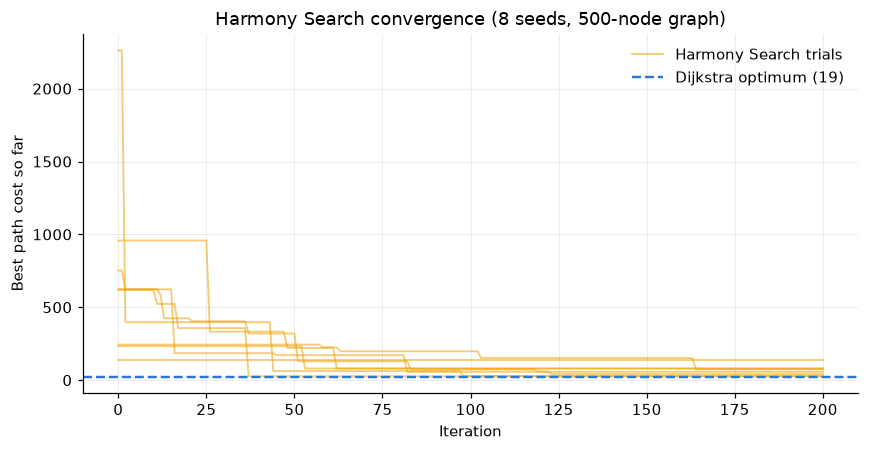

Most of the improvement happens early; the gap that remains at the end
is the price of using an approximate method.


In [8]:
# Cell 8 - convergence curves for each trial.
fig, ax = plt.subplots()
for i, run in enumerate(hs_runs):
    ax.plot(run.metadata["convergence"], color=COLORS["harmony_search"],
            alpha=0.55, linewidth=1.2, label="Harmony Search trials" if i == 0 else None)
ax.axhline(OPTIMAL, color=COLORS["dijkstra"], linestyle="--", linewidth=1.6,
           label=f"Dijkstra optimum ({OPTIMAL:,.0f})")
ax.set_xlabel("Iteration")
ax.set_ylabel("Best path cost so far")
ax.set_title("Harmony Search convergence (8 seeds, 500-node graph)")
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

print("Most of the improvement happens early; the gap that remains at the end")
print("is the price of using an approximate method.")

## 7. Head-to-head on one graph

All four algorithms, same graph, same query.

In [9]:
# Cell 9 - side-by-side comparison table.
rows = []
for name, res in [("dijkstra", result_dijkstra), ("bellman_ford", result_bellman),
                  ("astar", result_astar)]:
    rows.append([LABELS[name], f"{res.cost:,.0f}", "0.0%", f"{res.runtime_ms:.3f}",
                 f"{res.metadata['edge_examinations']:,}"])

hs_mean_cost = statistics.mean(costs)
rows.append([LABELS["harmony_search"], f"{hs_mean_cost:,.1f}",
             f"{(hs_mean_cost - OPTIMAL) / OPTIMAL:.1%}",
             f"{statistics.mean(times):.3f}",
             f"{statistics.mean(r.metadata['path_evaluations'] for r in hs_runs):,.0f} paths"])

table(["Algorithm", "Path cost", "Gap", "Runtime (ms)", "Basic operations"], rows)
print()
print("Note: the three exact algorithms all find the same cost, as they must.")
print("Harmony Search trades accuracy for nothing here - it is both slower AND worse")
print("on this graph. The next section asks whether that holds as graphs change.")

Algorithm       Path cost  Gap     Runtime (ms)  Basic operations
--------------  ---------  ------  ------------  ----------------
Dijkstra        19         0.0%    2.147         30,307          
Bellman-Ford    19         0.0%    25.654        184,368         
A*              19         0.0%    2.179         30,307          
Harmony Search  65.5       244.7%  96.734        230 paths       

Note: the three exact algorithms all find the same cost, as they must.
Harmony Search trades accuracy for nothing here - it is both slower AND worse
on this graph. The next section asks whether that holds as graphs change.


## 8. Research question 1 — how does this scale?

We hold density constant and grow the node count, measuring runtime and the
Harmony Search gap at each size.

In [10]:
# Cell 10 - scaling study across graph sizes.
SIZES = [50, 100, 250, 500, 1000]
scaling = []

for n in SIZES:
    g = generate_connected_graph(n, density="moderate", seed=7)
    s, t = 0, n - 1

    d = dijkstra(g, s, t)
    b = bellman_ford(g, s, t)
    hs = [harmony_search(g, s, t, hmcr=0.8, par=0.3, hms=30, iterations=150, seed=k)
          for k in range(5)]
    hs_cost = statistics.mean(r.cost for r in hs)

    scaling.append({
        "n": n, "edges": g.edge_count(),
        "dijkstra_ms": d.runtime_ms, "bellman_ms": b.runtime_ms,
        "hs_ms": statistics.mean(r.runtime_ms for r in hs),
        "optimal": d.cost, "hs_cost": hs_cost,
        "gap": (hs_cost - d.cost) / d.cost * 100,
    })
    print(f"  done n={n:>5,}  ({g.edge_count():,} edges)")

print()
table(["Nodes", "Edges", "Dijkstra ms", "Bellman ms", "HS ms", "Optimal", "HS cost", "HS gap"],
      [[f"{r['n']:,}", f"{r['edges']:,}", f"{r['dijkstra_ms']:.3f}", f"{r['bellman_ms']:.2f}",
        f"{r['hs_ms']:.1f}", f"{r['optimal']:,.0f}", f"{r['hs_cost']:,.1f}", f"{r['gap']:.1f}%"]
       for r in scaling])

  done n=   50  (188 edges)
  done n=  100  (688 edges)


  done n=  250  (3,991 edges)


  done n=  500  (15,444 edges)


  done n=1,000  (60,981 edges)

Nodes  Edges   Dijkstra ms  Bellman ms  HS ms  Optimal  HS cost  HS gap
-----  ------  -----------  ----------  -----  -------  -------  ------
50     188     0.036        0.32        4.5    51       67.2     31.8% 
100    688     0.131        1.11        10.9   52       79.8     53.5% 
250    3,991   0.204        6.73        24.9   9        32.4     260.0%
500    15,444  1.464        31.39       88.4   12       52.8     340.0%
1,000  60,981  7.699        115.11      307.7  10       77.6     676.0%


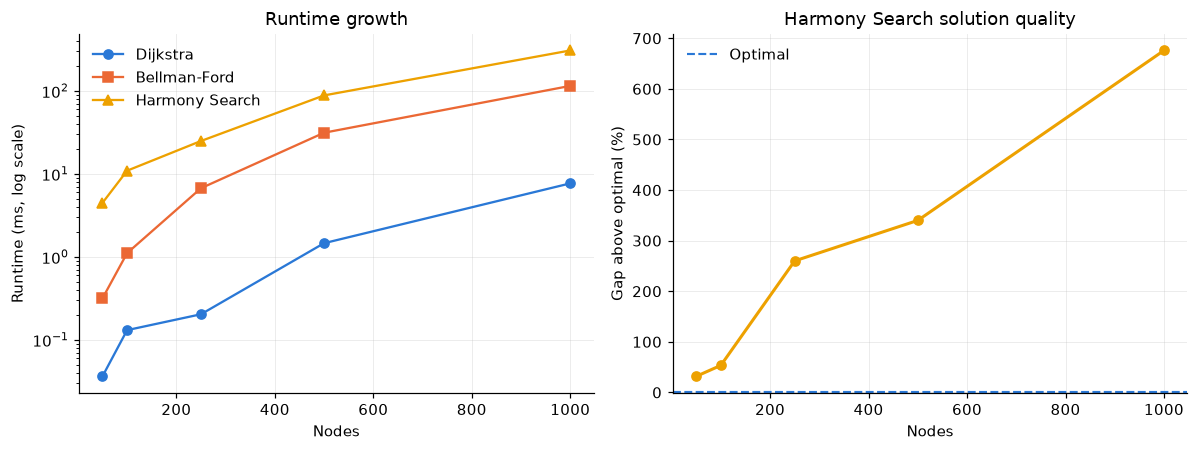

Harmony Search gap grows from 31.8% at 50 nodes
to 676.0% at 1,000 nodes.
Runtime is not the metaheuristic's real problem - solution quality is.


In [11]:
# Cell 11 - runtime growth (log scale) and solution-quality decay.
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.2))

ns = [r["n"] for r in scaling]
ax1.plot(ns, [r["dijkstra_ms"] for r in scaling], "o-", color=COLORS["dijkstra"], label="Dijkstra")
ax1.plot(ns, [r["bellman_ms"] for r in scaling], "s-", color=COLORS["bellman_ford"], label="Bellman-Ford")
ax1.plot(ns, [r["hs_ms"] for r in scaling], "^-", color=COLORS["harmony_search"], label="Harmony Search")
ax1.set_yscale("log")
ax1.set_xlabel("Nodes")
ax1.set_ylabel("Runtime (ms, log scale)")
ax1.set_title("Runtime growth")
ax1.legend(frameon=False)

ax2.plot(ns, [r["gap"] for r in scaling], "o-", color=COLORS["harmony_search"], linewidth=2)
ax2.axhline(0, color=COLORS["dijkstra"], linestyle="--", linewidth=1.4, label="Optimal")
ax2.set_xlabel("Nodes")
ax2.set_ylabel("Gap above optimal (%)")
ax2.set_title("Harmony Search solution quality")
ax2.legend(frameon=False)

plt.tight_layout()
plt.show()

print(f"Harmony Search gap grows from {scaling[0]['gap']:.1f}% at {scaling[0]['n']} nodes")
print(f"to {scaling[-1]['gap']:.1f}% at {scaling[-1]['n']:,} nodes.")
print("Runtime is not the metaheuristic's real problem - solution quality is.")

## 9. Research question 2 — do real networks behave like our generator?

Our generator draws each possible edge with fixed probability, so edge count
grows with **n²**. Real networks do not work that way: a road network has an
almost constant average degree no matter how large it gets.

We use three networks from the
[Stanford Large Network Dataset Collection](https://snap.stanford.edu/data/):

| Network | Domain | Full size |
|---|---|---|
| ego-Facebook | Social | 4,039 nodes / 88,234 edges |
| Oregon-1 | Internet AS routing | 10,670 nodes / 22,002 edges |
| roadNet-PA | Road network | 1,088,092 nodes / 1,541,898 edges |

Two modelling decisions have to be stated when citing these results:

1. **SNAP ships these graphs unweighted.** Routing needs weights, so each edge
   weight is derived from an order-independent hash of its endpoints plus a
   fixed seed, in the range 1–100. The same edge always gets the same weight,
   in the full graph and in any sample, so runs are reproducible.
2. **The large graphs are sampled.** Bellman-Ford is Θ(V·E), so the full
   million-node road network is not runnable in pure Python within a semester.
   A breadth-first sample stays connected by construction and preserves local
   structure.

In [12]:
# Cell 12 - download (once) and load the three real networks.
# 8000 matches the committed experiment in results/, so the numbers below
# reproduce the charts used in the report rather than diverging from them.
SAMPLE = 8000
real = {}

for key in ["facebook", "oregon1", "roadnet-pa"]:
    ds = get_dataset(key)
    t0 = time.perf_counter()
    loaded = load_snap_graph(ds, DATA_DIR, sample_size=SAMPLE)
    real[key] = loaded
    g = loaded.graph
    print(f"{ds.name:<32} {g.node_count():>6,} nodes  {g.edge_count():>7,} edges  "
          f"avg degree {2*g.edge_count()/g.node_count():>6.2f}   "
          f"(from {loaded.original_nodes:,} nodes, {time.perf_counter()-t0:.1f}s)")

synth = generate_connected_graph(SAMPLE, density="moderate", seed=101)
print(f"{'our synthetic generator':<32} {synth.node_count():>6,} nodes  "
      f"{synth.edge_count():>7,} edges  avg degree {2*synth.edge_count()/synth.node_count():>6.2f}")

ego-Facebook                      4,039 nodes   88,234 edges  avg degree  43.69   (from 4,039 nodes, 0.2s)


Oregon-1 autonomous systems       8,000 nodes   18,074 edges  avg degree   4.52   (from 10,670 nodes, 0.1s)


roadNet-PA                        8,000 nodes   11,916 edges  avg degree   2.98   (from 1,088,092 nodes, 2.3s)


our synthetic generator           8,000 nodes  3,847,777 edges  avg degree 961.94


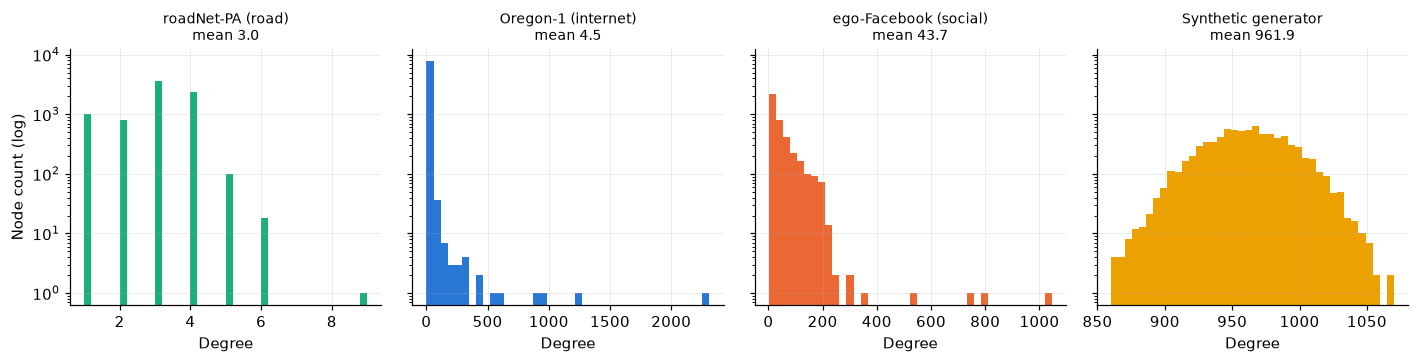

The road network is tightly clustered around degree 3. The social graph has a
long tail of hubs. Our generator produces a narrow bell curve at a much higher
degree - it resembles none of them. This is why real data was worth adding.


In [13]:
# Cell 13 - degree distributions: real topology vs our generator.
fig, axes = plt.subplots(1, 4, figsize=(13, 3.4), sharey=True)
panels = [
    ("roadnet-pa", "roadNet-PA (road)", "#1baf7a"),
    ("oregon1", "Oregon-1 (internet)", "#2a78d6"),
    ("facebook", "ego-Facebook (social)", "#eb6834"),
]

for ax, (key, title, colour) in zip(axes, panels):
    g = real[key].graph
    degs = [len(g.neighbors(n)) for n in g.iter_nodes()]
    ax.hist(degs, bins=40, color=colour, edgecolor="none")
    ax.set_yscale("log")
    ax.set_title(f"{title}\nmean {statistics.mean(degs):.1f}", fontsize=9)
    ax.set_xlabel("Degree")

degs = [len(synth.neighbors(n)) for n in synth.iter_nodes()]
axes[3].hist(degs, bins=40, color=COLORS["harmony_search"], edgecolor="none")
axes[3].set_yscale("log")
axes[3].set_title(f"Synthetic generator\nmean {statistics.mean(degs):.1f}", fontsize=9)
axes[3].set_xlabel("Degree")
axes[0].set_ylabel("Node count (log)")

plt.tight_layout()
plt.show()

print("The road network is tightly clustered around degree 3. The social graph has a")
print("long tail of hubs. Our generator produces a narrow bell curve at a much higher")
print("degree - it resembles none of them. This is why real data was worth adding.")

## 10. Research question 3 — does structure change the answer?

Same four algorithms, now on the three real networks.

In [14]:
# Cell 14 - run every algorithm on every real network.
real_results = {}

for key, loaded in real.items():
    g, s, t = loaded.graph, loaded.source, loaded.target
    d = dijkstra(g, s, t)
    b = bellman_ford(g, s, t)
    a = astar(g, s, t)
    # 10 trials at 250 iterations matches the committed experiment settings.
    hs = [harmony_search(g, s, t, hmcr=0.8, par=0.3, hms=30, iterations=250, seed=k)
          for k in range(10)]
    hs_cost = statistics.mean(r.cost for r in hs)
    real_results[key] = {
        "name": loaded.dataset.name, "optimal": d.cost, "hs_cost": hs_cost,
        "gap": (hs_cost - d.cost) / d.cost * 100,
        "dijkstra_ms": d.runtime_ms, "bellman_ms": b.runtime_ms, "astar_ms": a.runtime_ms,
        "hs_ms": statistics.mean(r.runtime_ms for r in hs),
        "hops": len(d.path),
        "degree": 2 * g.edge_count() / g.node_count(),
    }
    print(f"  done {loaded.dataset.name}")

print()
table(["Network", "Avg deg", "Hops", "Optimal", "HS cost", "HS gap", "Dijkstra ms", "HS ms"],
      [[r["name"][:26], f"{r['degree']:.2f}", r["hops"], f"{r['optimal']:,.0f}",
        f"{r['hs_cost']:,.1f}", f"{r['gap']:.1f}%", f"{r['dijkstra_ms']:.2f}", f"{r['hs_ms']:.0f}"]
       for r in real_results.values()])

  done ego-Facebook


  done Oregon-1 autonomous systems


  done roadNet-PA

Network                     Avg deg  Hops  Optimal  HS cost  HS gap  Dijkstra ms  HS ms
--------------------------  -------  ----  -------  -------  ------  -----------  -----
ego-Facebook                43.69    15    68       97.0     42.6%   16.87        6473 
Oregon-1 autonomous system  4.52     4     131      131.0    0.0%    12.20        966  
roadNet-PA                  2.98     40    1,530    1,730.0  13.1%   8.42         671  


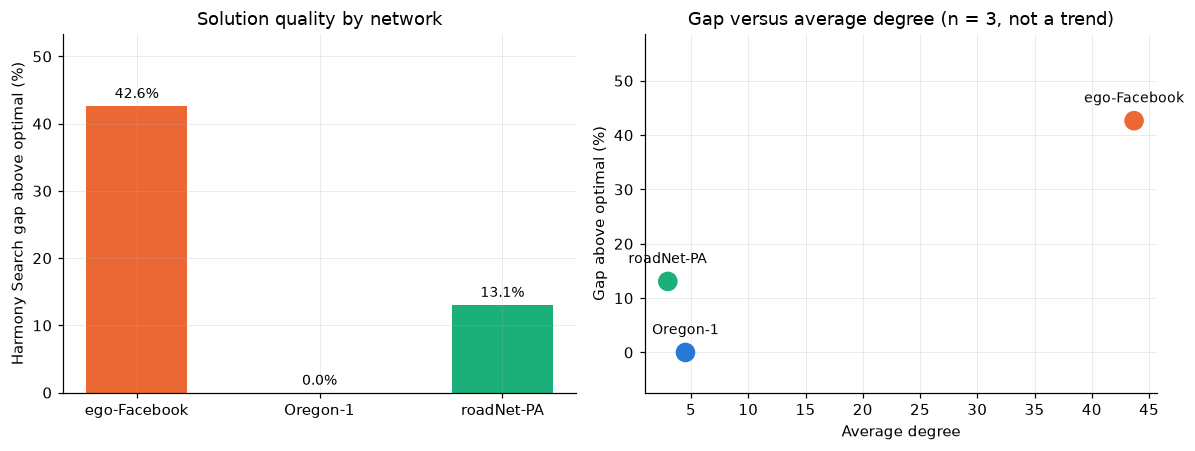

Ranked by Harmony Search accuracy:

Network                      Avg degree  Hops in optimal path  Optimal cost  HS gap
---------------------------  ----------  --------------------  ------------  ------
Oregon-1 autonomous systems  4.52        4                     131           0.0%  
roadNet-PA                   2.98        40                    1,530         13.1% 
ego-Facebook                 43.69       15                    68            42.6% 

All three graphs have the SAME node count, so size cannot explain the spread.
Structure clearly matters. But note the ordering is not monotonic in degree:
with only three networks we can see that structure changes the answer without
being able to say which structural property drives it. Two mechanisms are
visible in the table and they pull in opposite directions:

  * Long paths are hard to assemble step by step. roadNet-PA needs the most
    hops, and every hop is another chance to pick a worse edge.
  * A small optimal cost inflates th

In [15]:
# Cell 15 - the key finding: accuracy varies by network, not by size.
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.2))

names = [r["name"].split()[0] for r in real_results.values()]
gaps = [r["gap"] for r in real_results.values()]
degrees = [r["degree"] for r in real_results.values()]
bar_colours = ["#eb6834", "#2a78d6", "#1baf7a"]

bars = ax1.bar(names, gaps, color=bar_colours, width=0.55)
ax1.bar_label(bars, fmt="%.1f%%", padding=3, fontsize=9)
ax1.set_ylabel("Harmony Search gap above optimal (%)")
ax1.set_title("Solution quality by network")
ax1.set_ylim(0, max(gaps) * 1.25 if max(gaps) > 0 else 1)

ax2.scatter(degrees, gaps, s=140, color=bar_colours, zorder=3)
for name, deg, gap in zip(names, degrees, gaps):
    ax2.annotate(name, (deg, gap), textcoords="offset points", xytext=(0, 12),
                 ha="center", fontsize=9)
ax2.set_xlabel("Average degree")
ax2.set_ylabel("Gap above optimal (%)")
ax2.set_title("Gap versus average degree (n = 3, not a trend)")
ax2.set_ylim(-max(gaps) * 0.15 - 1, max(gaps) * 1.35 + 1)

plt.tight_layout()
plt.show()

ordered = sorted(real_results.values(), key=lambda r: r["gap"])
print("Ranked by Harmony Search accuracy:\n")
table(["Network", "Avg degree", "Hops in optimal path", "Optimal cost", "HS gap"],
      [[r["name"][:30], f"{r['degree']:.2f}", r["hops"], f"{r['optimal']:,.0f}", f"{r['gap']:.1f}%"]
       for r in ordered])

print()
print("All three graphs have the SAME node count, so size cannot explain the spread.")
print("Structure clearly matters. But note the ordering is not monotonic in degree:")
print("with only three networks we can see that structure changes the answer without")
print("being able to say which structural property drives it. Two mechanisms are")
print("visible in the table and they pull in opposite directions:")
print()
print("  * Long paths are hard to assemble step by step. roadNet-PA needs the most")
print("    hops, and every hop is another chance to pick a worse edge.")
print("  * A small optimal cost inflates the RELATIVE gap. On the dense social graph")
print("    the optimum is only a handful of cost units, so even a near-miss in")
print("    absolute terms looks large as a percentage.")
print()
print("Disentangling the two would need many more networks - a next-steps question,")
print("not something these three data points can settle.")

## 11. Runtime is not the only resource

`tracemalloc` measures peak memory. It distorts runtime badly, so these runs
are kept separate from the timing runs — the same separation the CSV output
makes with its `run_type` column.

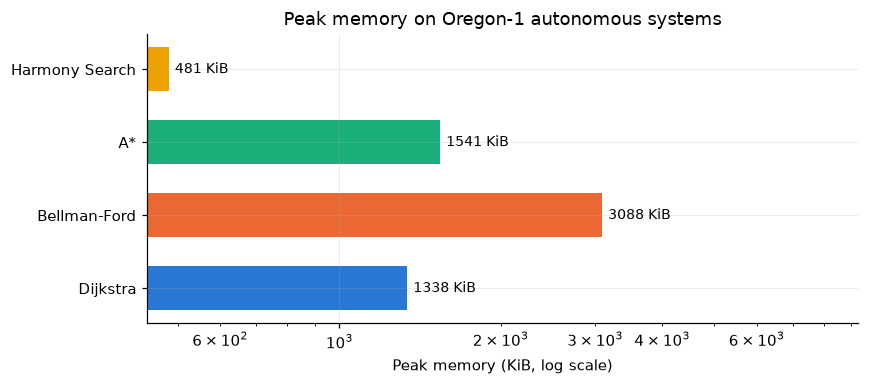

Bellman-Ford used the most memory (3,088 KiB), 6x more than Harmony Search.
Bellman-Ford materialises the whole edge list; the heap-based searches do not.


In [16]:
# Cell 16 - peak memory and basic operation counts.
import tracemalloc

def peak_kib(fn, *args, **kwargs):
    tracemalloc.start()
    try:
        fn(*args, **kwargs)
        _, peak = tracemalloc.get_traced_memory()
    finally:
        tracemalloc.stop()
    return peak / 1024

g = real["oregon1"].graph
s, t = real["oregon1"].source, real["oregon1"].target

mem = {
    "dijkstra": peak_kib(dijkstra, g, s, t),
    "bellman_ford": peak_kib(bellman_ford, g, s, t),
    "astar": peak_kib(astar, g, s, t),
    "harmony_search": peak_kib(harmony_search, g, s, t, hms=30, iterations=150, seed=1),
}

fig, ax = plt.subplots(figsize=(8, 3.6))
bars = ax.barh([LABELS[a] for a in ALGORITHMS], [mem[a] for a in ALGORITHMS],
               color=[COLORS[a] for a in ALGORITHMS], height=0.6)
ax.bar_label(bars, fmt="%.0f KiB", padding=4, fontsize=9)
ax.set_xscale("log")
ax.set_xlabel("Peak memory (KiB, log scale)")
ax.set_title(f"Peak memory on {real['oregon1'].dataset.name}")
ax.set_xlim(right=max(mem.values()) * 3)
plt.tight_layout()
plt.show()

heaviest = max(mem, key=mem.get)
lightest = min(mem, key=mem.get)
print(f"{LABELS[heaviest]} used the most memory ({mem[heaviest]:,.0f} KiB), "
      f"{mem[heaviest] / mem[lightest]:.0f}x more than {LABELS[lightest]}.")
print("Bellman-Ford materialises the whole edge list; the heap-based searches do not.")

## 12. Parameter tuning

Harmony Search has three tunable parameters. If poor settings were the reason
for its weak results, tuning should show it. We sweep all 27 combinations of
HMCR × PAR × HMS.

In [17]:
# Cell 17 - full HMCR x PAR x HMS sweep.
sweep_csv = ROOT / "results" / "raw" / "notebook_sweep.csv"
sweep_rows = run_parameter_sweep(sweep_csv, node_count=300, trials=3, iterations=80)

by_combo = {}
for row in sweep_rows:
    key = (float(row["hmcr"]), float(row["par"]), int(row["hms"]))
    by_combo.setdefault(key, []).append(float(row["path_cost"]))

means = {k: statistics.mean(v) for k, v in by_combo.items()}
best = min(means, key=means.get)
worst = max(means, key=means.get)

print(f"{len(sweep_rows)} runs across {len(means)} parameter combinations\n")
print(f"best   HMCR={best[0]}  PAR={best[1]}  HMS={best[2]}   mean cost {means[best]:,.1f}")
print(f"worst  HMCR={worst[0]}  PAR={worst[1]}  HMS={worst[2]}   mean cost {means[worst]:,.1f}")
print(f"spread between best and worst settings: {(means[worst]-means[best])/means[best]:.1%}")

81 runs across 27 parameter combinations

best   HMCR=0.9  PAR=0.3  HMS=50   mean cost 46.7
worst  HMCR=0.7  PAR=0.1  HMS=10   mean cost 95.3
spread between best and worst settings: 104.3%


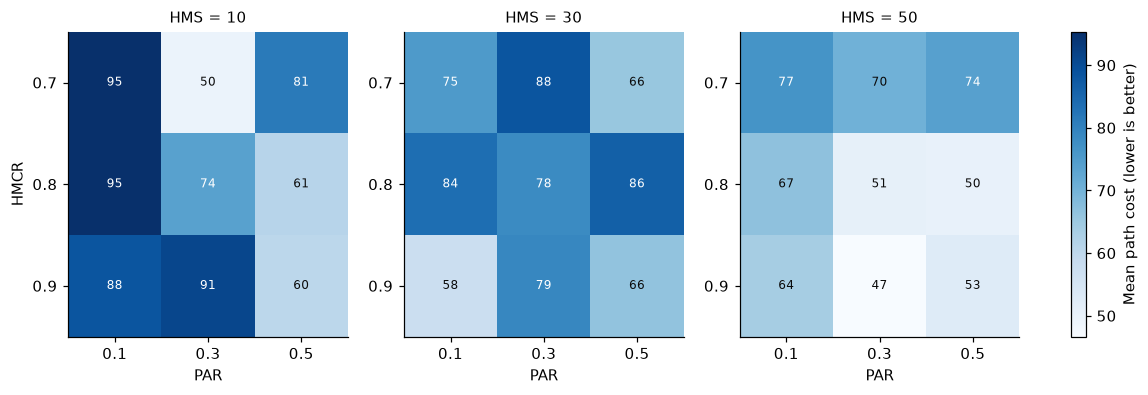

Darker means a worse (higher-cost) path. Tuning moves the result, but not
enough to close the gap to Dijkstra - the limitation is the method, not the
settings.


In [18]:
# Cell 18 - heatmaps of mean cost, one panel per HMS value.
hmcrs = sorted({k[0] for k in means})
pars = sorted({k[1] for k in means})
hmss = sorted({k[2] for k in means})

fig, axes = plt.subplots(1, len(hmss), figsize=(12, 3.6))
vmin, vmax = min(means.values()), max(means.values())

for ax, hms in zip(axes, hmss):
    grid = [[means[(h, p, hms)] for p in pars] for h in hmcrs]
    im = ax.imshow(grid, cmap="Blues", vmin=vmin, vmax=vmax, aspect="auto")
    ax.set_xticks(range(len(pars)), [str(p) for p in pars])
    ax.set_yticks(range(len(hmcrs)), [str(h) for h in hmcrs])
    ax.set_xlabel("PAR")
    ax.set_title(f"HMS = {hms}", fontsize=10)
    ax.grid(False)
    for i in range(len(hmcrs)):
        for j in range(len(pars)):
            value = grid[i][j]
            ax.text(j, i, f"{value:.0f}", ha="center", va="center", fontsize=8,
                    color="white" if value > (vmin + vmax) / 2 else "#0b0b0b")

axes[0].set_ylabel("HMCR")
fig.colorbar(im, ax=axes, label="Mean path cost (lower is better)", fraction=0.02)
plt.show()

print("Darker means a worse (higher-cost) path. Tuning moves the result, but not")
print("enough to close the gap to Dijkstra - the limitation is the method, not the")
print("settings.")

## 13. Conclusions

**On the research questions:**

1. **Scaling.** Dijkstra and A\* scale comfortably. Bellman-Ford's Θ(V·E) cost
   shows up clearly as graphs grow. Harmony Search stays affordable in runtime
   but its *accuracy* degrades sharply with size.

2. **Cost of approximation.** On these graphs Harmony Search is both slower and
   worse than Dijkstra. A metaheuristic pays off when the exact algorithm is
   infeasible — for single-pair shortest paths, it simply is not.

3. **Structure beats size.** The clearest result in this notebook. Three graphs
   with *identical node counts* produced very different Harmony Search accuracy
   — from finding the exact optimum on the internet AS graph to missing badly on
   the others. Size alone predicts nothing. Testing only on synthetic graphs
   would have hidden this entirely.

   We deliberately stop short of claiming *which* structural property is
   responsible. The ordering is not monotonic in average degree, and at least
   two mechanisms are visible in the data — long paths accumulate error hop by
   hop, while a small optimal cost inflates the relative gap. Three networks
   cannot separate those.

**Limitations we would fix given more time:**

- **A\* was never really tested.** With no coordinates there is no admissible
  heuristic, so it reduced to Dijkstra. A landmark (ALT) heuristic would make it
  a genuine fourth algorithm.
- **Bellman-Ford exits early** when a pass changes nothing, so it rarely reaches
  its worst case; its measured cost depends on edge ordering.
- **One query pair per graph.** Costs are single-instance rather than averaged
  over many source/target pairs.
- **Synthetic weights on real topology.** The structure is real; the weights are
  not. Weighted road data (for example the DIMACS challenge graphs) would remove
  that caveat and enable a distance heuristic.

**Next questions this raises:**

- Which structural property actually predicts Harmony Search accuracy? Testing
  across many more SNAP networks, with hop count and optimal cost recorded, would
  separate the two competing explanations above.
- Would a hybrid help — seeding harmony memory with a greedy or BFS path instead
  of random walks?
- Does the picture change for problems where no exact polynomial algorithm
  exists? Shortest path is arguably the worst possible showcase for a
  metaheuristic, because Dijkstra already solves it optimally and quickly.

In [19]:
# Cell 19 - final summary of everything measured.
print("=" * 74)
print("SUMMARY".center(74))
print("=" * 74)
print(f"\nSynthetic scaling ({len(SIZES)} sizes, {SIZES[0]}-{SIZES[-1]:,} nodes):")
for r in scaling:
    print(f"  {r['n']:>5,} nodes   Dijkstra {r['dijkstra_ms']:>7.3f} ms   "
          f"Bellman {r['bellman_ms']:>8.2f} ms   HS gap {r['gap']:>6.1f}%")

print(f"\nReal SNAP networks (each sampled to {SAMPLE:,} nodes):")
for r in real_results.values():
    print(f"  {r['name'][:30]:<32} avg degree {r['degree']:>5.2f}   HS gap {r['gap']:>6.1f}%")

print(f"\nParameter sweep: {len(sweep_rows)} runs, best/worst spread "
      f"{(means[worst]-means[best])/means[best]:.1%}")
print(f"\nAll figures produced on: {describe_environment()['processor']}")
print("Reproduce with: python -m routing_project.cli run-real")
print("=" * 74)

                                 SUMMARY                                  

Synthetic scaling (5 sizes, 50-1,000 nodes):
     50 nodes   Dijkstra   0.036 ms   Bellman     0.32 ms   HS gap   31.8%
    100 nodes   Dijkstra   0.131 ms   Bellman     1.11 ms   HS gap   53.5%
    250 nodes   Dijkstra   0.204 ms   Bellman     6.73 ms   HS gap  260.0%
    500 nodes   Dijkstra   1.464 ms   Bellman    31.39 ms   HS gap  340.0%
  1,000 nodes   Dijkstra   7.699 ms   Bellman   115.11 ms   HS gap  676.0%

Real SNAP networks (each sampled to 8,000 nodes):
  ego-Facebook                     avg degree 43.69   HS gap   42.6%
  Oregon-1 autonomous systems      avg degree  4.52   HS gap    0.0%
  roadNet-PA                       avg degree  2.98   HS gap   13.1%

Parameter sweep: 81 runs, best/worst spread 104.3%

All figures produced on: Intel64 Family 6 Model 183 Stepping 1, GenuineIntel
Reproduce with: python -m routing_project.cli run-real
